<img src="assets/DemoSlidesForExport_0.png" alt="" style="max-width: 100%; max-height: 88vh; width: auto; height: auto; object-fit: contain; display: block; margin: 0 auto;" />

<img src="assets/DemoSlidesForExport_1.png" alt="" style="max-width: 100%; max-height: 88vh; width: auto; height: auto; object-fit: contain; display: block; margin: 0 auto;" />

<img src="assets/mCDR-2step_0.png" alt="" style="max-width: 100%; max-height: 88vh; width: auto; height: auto; object-fit: contain; display: block; margin: 0 auto;" />

<img src="assets/mCDR-2step_1.png" alt="" style="max-width: 100%; max-height: 88vh; width: auto; height: auto; object-fit: contain; display: block; margin: 0 auto;" />

<img src="assets/mCDR-2step_2.png" alt="" style="max-width: 100%; max-height: 88vh; width: auto; height: auto; object-fit: contain; display: block; margin: 0 auto;" />

<img src="assets/mCDR-2step_3.png" alt="" style="max-width: 100%; max-height: 88vh; width: auto; height: auto; object-fit: contain; display: block; margin: 0 auto;" />

<div style="background-color: #b8cde0; padding: 30px; min-height: 80vh; width: 100%; box-sizing: border-box;">
<h1 style="margin: 0 0 0.8rem 0; font-size: clamp(1.4rem, 3vw, 2.2rem);">C-Star Initialization</h1>
<p style="font-size: large; line-height: 1.45; margin: 0;">
C-Star consists of python packages that are installable via <code>pip</code> — the standard Python package installer.
</p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Carbon-accounting coastal model simulations and analysis can be run using imported python objects.
</p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Begin by importing python package(s), and checking the environment:
</p>
</div>

In [1]:
%load_ext autoreload
%autoreload 2

from datetime import datetime
from IPython.display import Markdown, display

import cson_forge as CStar_Forge
import roms_tools as rt

env = CStar_Forge.config.get_environment_info()

# Display summary
summary = f"""
### Machine Information
- **Hostname**: `{env.hostname}`
- **System Tag**: `{env.system_tag}`
- **OS**: `{env.os_info}`

### Environment Summary
- **Python Version**: `{env.python_version}`
- **Python Executable**: `{env.python_executable}`
- **Conda/Micromamba Environment**: `{env.env_info}`
- **Kernel**: `{env.kernel_spec}`
"""

display(Markdown(summary))
print(f"Execution timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")



### Machine Information
- **Hostname**: `hoatzin`
- **System Tag**: `MacOS`
- **OS**: `Darwin 23.6.0 (arm64)`

### Environment Summary
- **Python Version**: `3.13.13`
- **Python Executable**: `/Users/blsaenz/miniforge3/envs/cworthy-test/bin/python`
- **Conda/Micromamba Environment**: `cworthy-test (/Users/blsaenz/miniforge3/envs/cworthy-test)`
- **Kernel**: `unknown`


Execution timestamp: 2026-04-28 23:13:31


<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Define the dimensions that will build a ROMS model grid with plain-language names:
</p>

In [15]:
# Grid parameters ------------------------------------------------------------------
grid_name = "Gulf_of_Alaska_sm"
grid_settings = dict[str, float](
    # nx=208,              # X-direction grid cells (xi)
    # ny=192,              # Y-direction grid cells (eta)
    nx=320,              # X-direction grid cells (xi)
    ny=160,              # Y-direction grid cells (eta)
    size_x=1460,         # km (longitude direction at ~49N)
    size_y=700,         # km (latitude direction)
    #center_lon=-139.5,   
    #center_lat=53,
    center_lon=-150.0,   
    center_lat=57.5,
    rot=41,              # rotation of grid (degrees)
    N=10,                # number of vertical levels
    #N=50,                # number of vertical levels
    theta_s=6.0,         # surface control parameter
    theta_b=3.0,         # bottom control parameter
    hc=250.0,            # critical depth
    #close_narrow_channels=True,
)
boundaries = {
        "south": True,
        "east": False,
        "north": True,
        "west": True, 
}
print("\nGrid options loaded.\n")


Grid options loaded.



<p style="font-size: large; line-height: 1.45; margin: 0;">
Next we define a test model, using a pre-defined ROMS-MARBL model specification (a <b>model_spec</b>, which contains settings to enable ROMS-MARBL features and compilation to match your inputs and environment), and start and end dates.
</p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
These changeable options are passed to the CstarSpecBuilder() object, which will find and generate the <b>forcing data</b>, and <b>C-Star blueprints</b> which will run the ROMS model and ensure <b>scientific reproducability<b>:
</p>

CstarSpecBuilder: planned NetCDF outputs
  - /Users/blsaenz/cson-forge-data/input-data/cson_roms-marbl_v0_1_Gulf_of_Alaska_sm_8procs/cson_roms-marbl_v0_1_Gulf_of_Alaska_sm_8procs_grid.nc
  - /Users/blsaenz/cson-forge-data/input-data/cson_roms-marbl_v0_1_Gulf_of_Alaska_sm_8procs/cson_roms-marbl_v0_1_Gulf_of_Alaska_sm_8procs_initial_conditions.nc
  - /Users/blsaenz/cson-forge-data/input-data/cson_roms-marbl_v0_1_Gulf_of_Alaska_sm_8procs/cson_roms-marbl_v0_1_Gulf_of_Alaska_sm_8procs_surface-physics.nc
  - /Users/blsaenz/cson-forge-data/input-data/cson_roms-marbl_v0_1_Gulf_of_Alaska_sm_8procs/cson_roms-marbl_v0_1_Gulf_of_Alaska_sm_8procs_surface-bgc.nc
  - /Users/blsaenz/cson-forge-data/input-data/cson_roms-marbl_v0_1_Gulf_of_Alaska_sm_8procs/cson_roms-marbl_v0_1_Gulf_of_Alaska_sm_8procs_boundary-physics.nc
  - /Users/blsaenz/cson-forge-data/input-data/cson_roms-marbl_v0_1_Gulf_of_Alaska_sm_8procs/cson_roms-marbl_v0_1_Gulf_of_Alaska_sm_8procs_boundary-bgc.nc
  - /Users/blsaenz/cson-forge-d

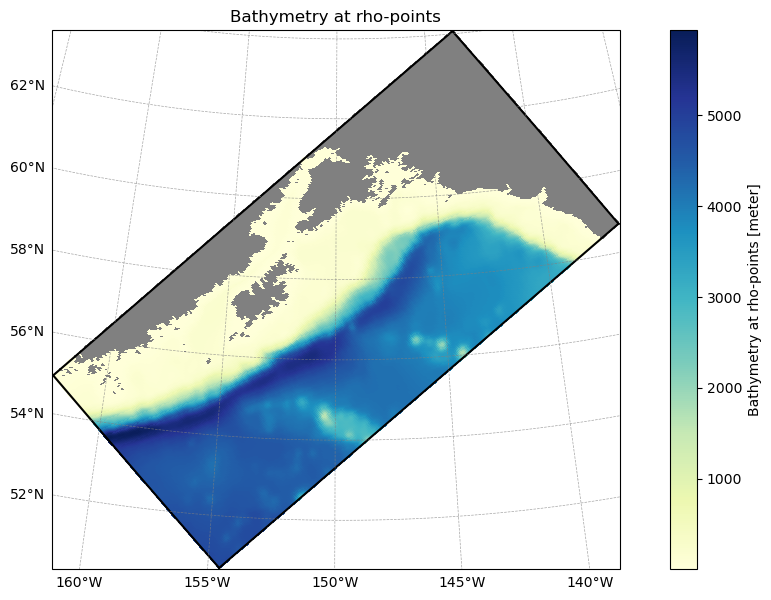

In [16]:
#Change to roms-tools grid gen, for plotting

# Model setup ------------------------------------------------------------------
model_spec = "cson_roms-marbl_v0.1"
start_time = datetime(2010, 1, 1)
end_time = datetime(2010, 1, 10)

partitioning = {
    "n_procs_x": 4, # number of partitions in xi (x) 
    "n_procs_y": 2, # number of partitions in eta (y) 
}

# Initialize CstarSpecBuilder --------------------------------------------------
ocn = CStar_Forge.CstarSpecBuilder(
    description="GulfOfAlaska_sm",
    model_name=model_spec,
    grid_name=grid_name,
    grid_kwargs=grid_settings,
    open_boundaries=boundaries,    
    start_time=start_time,
    end_time=end_time,
    partitioning=partitioning,
    CDR_forcing=cdr_list,
)

ocn.grid.plot()

Possibilities:  Change grid rotation.  

<div style="background-color: #b8cde0; padding: 30px; min-height: 80vh; width: 100%; box-sizing: border-box;">
<h1 style="margin: 0 0 0.8rem 0; font-size: clamp(1.4rem, 3vw, 2.2rem);">C-Star: Develop CDR forcing</h1>
<p style="font-size: large; line-height: 1.45; margin: 0;">
A CDR intervention can be planned and built by C-star. Here we add the requirements to the CStarSpecBuilder to create modified blueprints and ROMS-MARBL input files in order to add alkalinity (at a location, details on amount): </p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Maybe details here, showing code chages.</p>
</div>

In [6]:
# make CDR forcing?  Or, have Forge do it?

# plot CDR forcing

times = [datetime(2010, 1, 1, 0),
           datetime(2010, 1, 2, 0),
           datetime(2010, 1, 6, 0),
          ]
volume_fluxes = [0, 100, 500] # m3/s
tracer_fluxes = {"ALK": [0.0, 30.0*10**6, 0.0]} # meq/s
tracer_concentrations = {
    "ALK": [1900.0, 2100.0, 1900.0],  # meq/m3
    "temp": 20.0,  # degrees C
    "salt": 1.0,  # psu
}

cdr_tracer_release1 = rt.TracerPerturbation(
name="release_1",
    lat=59.64,  # degree N
    lon=211.12,  # degree E
    depth=2,  # m
    hsc=500,
    vsc=300,
    times=times,
    tracer_fluxes=tracer_fluxes
)

cdr_volume_release1 = rt.VolumeRelease(
    name="v_release1",
    lat=57.88,  # degree N
    lon=360.-151.67,  # degree E
    depth=2,  # m
    times=times,
    volume_fluxes=volume_fluxes,
    tracer_concentrations=tracer_concentrations,
)

cdr_list = [cdr_tracer_release1] #,cdr_volume_release1]

<div style="background-color: #b8cde0; padding: 30px; min-height: 80vh; width: 100%; box-sizing: border-box;">
<h1 style="margin: 0 0 0.8rem 0; font-size: clamp(1.4rem, 3vw, 2.2rem);">C-Star Forcing Data and Blueprint Generation</h1>
<p style="font-size: large; line-height: 1.45; margin: 0;">
C-Star uses online, published datasets for ocean bathymetry, atmospheric variables, and initial and boundary conditions. These datasets are either steamable directly to C-Star or are staged online by C-Worthy. Data sources are specified in the 
</p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Carbon-accounting coastal model simulations and analysis can be run using imported python objects.
</p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Begin by importing python package(s), and checking the environment:
</p>

In [17]:
#%%prun
#%load_ext line_profiler
# ensure that source data is staged locally
ocn.ensure_source_data()

# prepare model input
#%lprun -f ocn.generate_inputs(clobber=False) # setting clobber=True will overwrite existing files
ocn.generate_inputs(clobber=False) # setting clobber=True will overwrite existing files

# configure and build the model
ocn.configure_build(
    compile_time_settings={}, 
    run_time_settings = {}
    #     "roms.in": {
    #         "time_stepping": {
    #             "dt": 900,
    #         }
    #     }
    # }
)

✔️  Using existing GLORYS_REGIONAL file for 2009-12-31: cmems_mod_glo_phy_my_0.083deg_P1D-m_REGIONAL_Gulf_of_Alaska_sm_20091231.nc
✔️  Using existing GLORYS_REGIONAL file for 2010-01-01: cmems_mod_glo_phy_my_0.083deg_P1D-m_REGIONAL_Gulf_of_Alaska_sm_20100101.nc
✔️  Using existing GLORYS_REGIONAL file for 2010-01-02: cmems_mod_glo_phy_my_0.083deg_P1D-m_REGIONAL_Gulf_of_Alaska_sm_20100102.nc
✔️  Using existing GLORYS_REGIONAL file for 2010-01-03: cmems_mod_glo_phy_my_0.083deg_P1D-m_REGIONAL_Gulf_of_Alaska_sm_20100103.nc
✔️  Using existing GLORYS_REGIONAL file for 2010-01-04: cmems_mod_glo_phy_my_0.083deg_P1D-m_REGIONAL_Gulf_of_Alaska_sm_20100104.nc
✔️  Using existing GLORYS_REGIONAL file for 2010-01-05: cmems_mod_glo_phy_my_0.083deg_P1D-m_REGIONAL_Gulf_of_Alaska_sm_20100105.nc
✔️  Using existing GLORYS_REGIONAL file for 2010-01-06: cmems_mod_glo_phy_my_0.083deg_P1D-m_REGIONAL_Gulf_of_Alaska_sm_20100106.nc
✔️  Using existing GLORYS_REGIONAL file for 2010-01-07: cmems_mod_glo_phy_my_0.083d

2026-04-29 03:41:27,358 [WARNING] - utils.py:109 - Optional variables missing (but not critical): ['Lig', 'DIC_ALT_CO2', 'Alk_ALT_CO2']


[########################################] | 100% Completed | 4.62 sms

▶️  [3/9] Generating surface forcing...
[########################################] | 100% Completed | 429.12 ms
[########################################] | 100% Completed | 1.87 sms

▶️  [4/9] Generating surface forcing...


2026-04-29 03:50:04,279 [WARNING] - utils.py:109 - Optional variables missing (but not critical): ['pco2_air_alt']


[########################################] | 100% Completed | 419.59 ms

▶️  [5/9] Generating boundary forcing...


2026-04-29 03:50:05,017 [WARNING] - boundary_forcing.py:835 - The northern boundary is divided by land. It would be safer (but slower and more memory-intensive) to use `apply_2d_horizontal_fill = True`.
2026-04-29 03:50:05,433 [WARNING] - boundary_forcing.py:835 - The western boundary is divided by land. It would be safer (but slower and more memory-intensive) to use `apply_2d_horizontal_fill = True`.


[########################################] | 100% Completed | 314.31 ms
[########################################] | 100% Completed | 2.88 sms


2026-04-29 03:50:09,573 [WARNING] - utils.py:109 - Optional variables missing (but not critical): ['Lig', 'DIC_ALT_CO2', 'Alk_ALT_CO2']



▶️  [6/9] Generating boundary forcing...
[########################################] | 100% Completed | 4.44 sms

▶️  [7/9] Generating tidal forcing...
[########################################] | 100% Completed | 2.81 sms

▶️  [8/9] Generating river forcing...

▶️  [9/9] Generating CDR forcing...

✅ All input files generated.



ROMSSimulation(
name = cson_roms-marbl_v0.1_Gulf_of_Alaska_sm_8procs,
directory = /Users/blsaenz/cson-forge-data/cson-forge-run/cson_roms-marbl_v0.1_Gulf_of_Alaska_sm_8procs_20100101-20100110,
start_date = 2010-01-01 00:00:00,
end_date = 2010-01-10 00:00:00,
valid_start_date = 2010-01-01 00:00:00,
valid_end_date = 2010-01-10 00:00:00,
discretization = ROMSDiscretization(time_step = 360, n_procs_x = 4, n_procs_y = 2),
codebase = <ROMSExternalCodeBase instance>,
runtime_code = <AdditionalCode instance>,
compile_time_code = <AdditionalCode instance>
model_grid = <ROMSModelGrid instance>,
initial_conditions = <ROMSInitialConditions instance>,
tidal_forcing = <ROMSTidalForcing instance>,
river_forcing = <ROMSRiverForcing instance>,
surface_forcing = <list of 3 ROMSSurfaceForcing instances>,
boundary_forcing = <list of 3 ROMSBoundaryForcing instances>,
)

<div style="background-color: #b8cde0; padding: 30px; min-height: 80vh; width: 100%; box-sizing: border-box;">
<h1 style="margin: 0 0 0.8rem 0; font-size: clamp(1.4rem, 3vw, 2.2rem);">C-Star: Run ROMS-MARBL from Blueprint</h1>
<p style="font-size: large; line-height: 1.45; margin: 0;">
Core C-Star functionality, like running a blueprint, is grouped into high-level commands </p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Here we check the blueprint produced in the previous steps, and then compile and ROMS-MARBL and follow the blueprint to perform a model integration.</p>
</div>

In [18]:
%%time
target_dir = "/Users/blsaenz/Projects/git/cson-forge/cson_forge/blueprints/MacOS/cson_roms-marbl_v0.1_Gulf_of_Alaska_sm_8procs"
%cd $target_dir

!zsh -c "cstar blueprint check B_cson_roms-marbl_v0.1_Gulf_of_Alaska_sm_8procs_build.yml"

!zsh -c 'cstar blueprint run B_cson_roms-marbl_v0.1_Gulf_of_Alaska_sm_8procs_build.yml --clobber'
# !zsh -c 'export DYLD_FALLBACK_LIBRARY_PATH="/opt/homebrew/opt/netcdf/lib:/opt/homebrew/opt/netcdf-fortran/lib:$DYLD_FALLBACK_LIBRARY_PATH" && cstar blueprint run B_cson_roms-marbl_v0.1_Gulf_of_Alaska_8procs_build.yml --clobber'



/Users/blsaenz/Projects/git/cson-forge/cson_forge/blueprints/MacOS/cson_roms-marbl_v0.1_Gulf_of_Alaska_sm_8procs
The blueprint `cson_roms-marbl_v0.1_Gulf_of_Alaska_sm_8procs` is valid
2026-04-29 00:55:56,399 [INFO] - simulation.py:1243 - 🛠️ Configuring ROMSSimulation
2026-04-29 00:55:56,399 [INFO] - simulation.py:1246 - 🔧 Setting up ROMSExternalCodeBase...
2026-04-29 00:56:05,968 [INFO] - simulation.py:1246 - 🔧 Setting up MARBLExternalCodeBase...
2026-04-29 00:56:19,233 [INFO] - simulation.py:1260 - 📦 Fetching compile-time code...
2026-04-29 00:56:19,246 [INFO] - simulation.py:1265 - 📦 Fetching runtime code... 
2026-04-29 00:56:19,248 [INFO] - simulation.py:1270 - 📦 Fetching input datasets...
2026-04-29 00:56:19,349 [INFO] - input_dataset.py:97 - 🔗 Created symlink: /Users/blsaenz/cson-forge-data/cson-forge-run/cson_roms-marbl_v0.1_Gulf_of_Alaska_sm_8procs_20100101-20100110/work/cdr.nc → /Users/blsaenz/cson-forge-data/cson-forge-run/cson_roms-marbl_v0.1_Gulf_of_Alaska_sm_8procs_20100101

Alternate CStar-Forge ROMS-MARBL build and compute methods, the hook into Cstar python. The preferred way of running is uisng the C-Star CLI (command line interface).

In [ ]:
import cstar.execution.handler as handler

ocn.build()
# perform partitioning
ocn.pre_run()

# run the model
exec_handler = ocn.run()
print(exec_handler)


Code to monitor the blueprint execution; not needed with C-Star CLI

In [ ]:
%%time

while not handler.ExecutionStatus.is_terminal(exec_handler.status):
    print("...", end="", flush=True)
    time.sleep(30)

if exec_handler.status == handler.ExecutionStatus.COMPLETED:
    print()
    print("Completed")
    ocn.post_run()
else:
    raise Exception("Model run failed")

<div style="background-color: #b8cde0; padding: 30px; min-height: 80vh; width: 100%; box-sizing: border-box;">
<h1 style="margin: 0 0 0.8rem 0; font-size: clamp(1.4rem, 3vw, 2.2rem);">C-Star: Analyze ROMS_MARBL output</h1>
<p style="font-size: large; line-height: 1.45; margin: 0;">
After bueprint or workplan execution finishes, modeled results can be examined and summaried using ROMS-Tools </p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Here we check the blueprint produced in the previous steps, and then compile and ROMS-MARBL and follow the blueprint to perform a model integration.</p>
</div>

First, Last output times:  2010-01-01 23:54:00 2010-01-10 00:00:00


KeyError: "Missing required variables in ds: ['avg_begin_time', 'avg_end_time', 'ALK_source', 'FG_CO2', 'FG_ALT_CO2', 'hDIC', 'hDIC_ALT_CO2']"

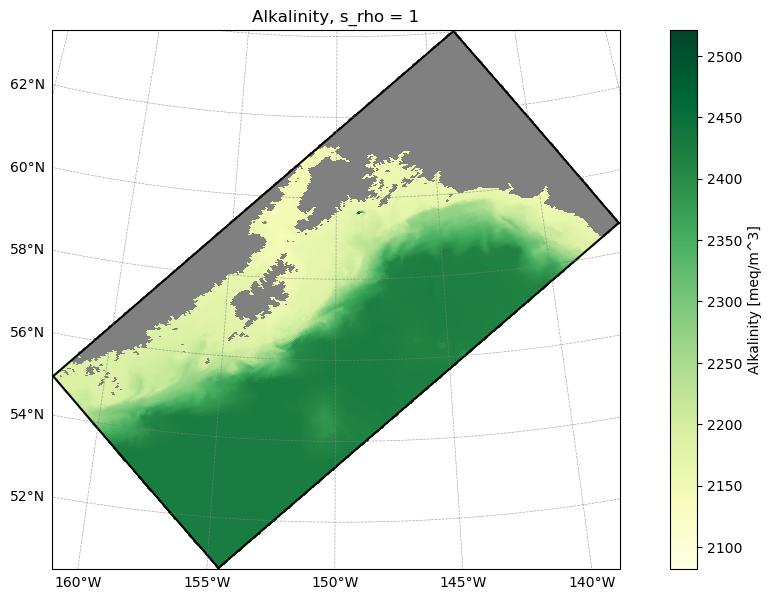

In [27]:
from roms_tools import Grid, ROMSOutput
import pandas as pd
import os,glob

run = "/Users/blsaenz/cson-forge-data/cson-forge-run/cson_roms-marbl_v0.1_Gulf_of_Alaska_sm_8procs_20100101-20100110"

#grid = Grid.from_file(os.path.join(run,"input","input_datasets","cson_roms-marbl_v0_1_Gulf_of_Alaska_8procs_grid.nc"))
roms_output = ROMSOutput(
    grid=ocn.grid,
    path=os.path.join(run,'joined_output','output_rst.*.nc')
)

time_index = pd.DatetimeIndex(roms_output.ds.time.values)
print('First, Last output times: ',time_index[0],time_index[-1])
roms_output.plot("ALK", time=4, s=1)
#roms_output.cdr_metrics()